<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Deep-Neural-Network/blob/master/LAB_5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task: Goldfish-to-shark adversarial attack

You are given a set of images that are classified by a model trained on Imagenet as a goldfish (class `GOLDFISH_LABEL=1`).<br>
Your task is to compute a strip of pixels of height 10, which, when pasted into the top 10 rows of *each* of the original images, makes the model classify each image as a shark (class `SHARK_LABEL=2`) with returned probability at least 0.5.

This should run under 2 minutes on CPU.

## Data

Below you can find a piece of code that download a zipfile and displays the images.

In [ ]:
import PIL.Image
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import zipfile
from io import BytesIO
from PIL import Image
from torch import Tensor
from torchvision.transforms import v2
from typing import cast

from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD


torch.use_deterministic_algorithms(True)


def get_images(
    url: str = "https://www.mimuw.edu.pl/~cygan/goldfish.zip",
    target_height: int = 100,
    target_width: int = 100,
) -> list[Tensor]:
    """Return five images as tensors of shape (C=3, H=target_height, W=target_width), 0..1 values."""
    request = requests.get(url)
    images = []
    with zipfile.ZipFile(BytesIO(request.content)) as z:
        for filename in z.namelist():
            if not filename.lower().endswith((".jpg", ".jpeg")):
                continue
            with z.open(filename) as f:
                images.append(Image.open(f).convert("RGB"))

    transformations = v2.Compose([
        v2.Resize(size=(target_height, target_width)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),  # scale to 0..1
    ])
    return [cast(Tensor, transformations(img)) for img in images]


def tensor_to_pil(image: Tensor) -> PIL.Image.Image:
    """Convert image tensor of shape (C, H, W), values 0..1, to PIL Image."""
    C, H, W = image.shape
    image = image.detach().permute(1, 2, 0).clone()  # to (H, W, C)
    img = PIL.Image.fromarray((image.numpy() * 255).astype(np.uint8))
    return img


normalize_colors = v2.Normalize(
    mean=IMAGENET_DEFAULT_MEAN,
    std=IMAGENET_DEFAULT_STD
)

torch.Size([3, 100, 100])


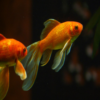

torch.Size([3, 100, 100])


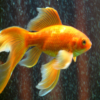

torch.Size([3, 100, 100])


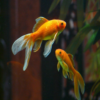

torch.Size([3, 100, 100])


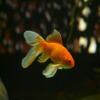

torch.Size([3, 100, 100])


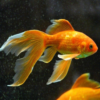

In [ ]:
images = get_images()
for img in images:
    print(img.shape)
    display(tensor_to_pil(img))

## Model

We will be using the `mobilenet_v2` model, trained to do classification on the Imagenet dataset.
For this task, the model is a black-box: you do not have to know the details of the model's architecture.
In particular the model's weights should not be changed.

In [ ]:
import torch.nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

DEFAULT_DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

def get_model(device: str = DEFAULT_DEVICE) -> torch.nn.Module:
    """Load a pretrained MobileNetV2 model.

    Input: normalized (not 0..1) images of shape (B, C, H, W),
    Output: logits (not probabilities or logprobs) of shape (B, num_classes=1000,).
    """
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    model.to(torch.device(device))
    model.eval()
    model.requires_grad_(False)
    return model

GOLDFISH_LABEL = MobileNet_V2_Weights.IMAGENET1K_V1.meta["categories"].index("goldfish")
SHARK_LABEL = MobileNet_V2_Weights.IMAGENET1K_V1.meta["categories"].index("great white shark")
GOLDFISH_LABEL, SHARK_LABEL

(1, 2)

In [ ]:
model = get_model()
model

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

## Evaluation

Below is a piece of code for:
* pasting the strip and running model inference on a normalized image;
* evaluating how well a strip performs, for this attack task.

In [ ]:
STRIP_HEIGHT = 10

def evaluate_strip(model: torch.nn.Module, images: list[Tensor], strip: Tensor) -> None:
    """
    Print goldfish and shark probabilities for each image with the given strip pasted on top,
    and display the resulting images.

    Args:
    - model: the classification model.
    - images: list of tensors of shape (3, H, W), values 0..1
    - strip: tensor of shape (3, STRIP_HEIGHT, W), values 0..1.
    """
    C, H, W = images[0].shape
    assert strip.shape == (C, STRIP_HEIGHT, W)
    assert strip.min() >= 0 and strip.max() <= 1, f"Strip should be 0..1, got {strip.min()=}, {strip.max()=}."

    device = next(model.parameters()).device

    for img in images:
        img = img.clone().to(device)
        img[:, :strip.shape[1], :] = strip.to(device)

        # Display the image with the strip
        display(tensor_to_pil(img.cpu()))

        img = normalize_colors(img)
        logits = model(img.unsqueeze(0)).squeeze(0)  # Shape (num_classes=1000,)
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        p_goldfish, p_shark = probabilities[[GOLDFISH_LABEL, SHARK_LABEL]]
        print(f'Probabilities assigned to: goldfish={p_goldfish:.5%}, shark={p_shark:.5%}.')


zero_strip = torch.zeros(3, STRIP_HEIGHT, images[0].shape[2])
# evaluate_strip(model, images, zero_strip) # Comment out or remove the zero strip evaluation

## TO IMPLEMENT

Here you have to implement the function that finds the strip.


In [ ]:
def calculate_strip(model: torch.nn.Module, images: list[Tensor], seed: int = 1, quiet: bool = False) -> Tensor:
    device = next(model.parameters()).device
    torch.manual_seed(seed)

    C, H, W = images[0].shape
    strip = torch.rand(C, STRIP_HEIGHT, W, device=device, requires_grad=True)

    optimizer = torch.optim.Adam([strip], lr=0.01)
    n_epochs = 250

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        total_loss = 0
        shark_probabilities = []

        for image in images:
            # Process Images
            image = image.clone().to(device)
            image[:, :STRIP_HEIGHT, :] = strip # Paste the strip
            image = normalize_colors(image)
            logits = model(image.unsqueeze(0)).squeeze(0) # Get logits
            probabilities = torch.nn.functional.softmax(logits, dim=-1)
            p_goldfish, p_shark = probabilities[[GOLDFISH_LABEL, SHARK_LABEL]]
            shark_probabilities.append(p_shark.item())

            loss = -torch.log(p_shark)
            total_loss += loss


        avg_loss = total_loss / len(images)

        # 5. Backpropagate
        avg_loss.backward()

        # 6. Update Strip
        optimizer.step()

        # 7. Clip Strip Values to stay in [0, 1] range
        with torch.no_grad():
             strip.clamp_(0, 1)


        # 8. Check Condition
        avg_shark_probability = np.mean(shark_probabilities)
        if not quiet and (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Avg Loss: {avg_loss.item():.4f}, Avg Shark Probability: {avg_shark_probability:.5%}')



    # 9. Return Strip
    return strip

Epoch 50/250, Avg Loss: 12.7546, Avg Shark Probability: 0.00458%
Epoch 100/250, Avg Loss: 5.8723, Avg Shark Probability: 1.34937%
Epoch 150/250, Avg Loss: 1.1223, Avg Shark Probability: 40.34820%
Epoch 200/250, Avg Loss: 0.2755, Avg Shark Probability: 76.45507%
Epoch 250/250, Avg Loss: 0.1528, Avg Shark Probability: 85.94990%

Evaluating the adversarial strip:


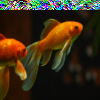

Probabilities assigned to: goldfish=0.09822%, shark=88.89745%.


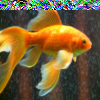

Probabilities assigned to: goldfish=4.52956%, shark=78.98092%.


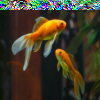

Probabilities assigned to: goldfish=0.00195%, shark=92.25041%.


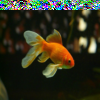

Probabilities assigned to: goldfish=0.00185%, shark=83.87692%.


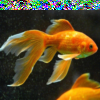

Probabilities assigned to: goldfish=1.06714%, shark=86.25796%.


In [ ]:
adversarial_strip = calculate_strip(model, images, quiet=False)

print("\nEvaluating the adversarial strip:")
evaluate_strip(model, images, adversarial_strip)